# Heart Disease Prediction System - Machine Learning Notebook

**Internship Capstone Project (Week 4)**

This notebook covers the full ML workflow:
Dataset -> Data Cleaning -> EDA -> Preprocessing -> Feature Engineering ->
Model Training -> Evaluation -> Model Selection -> Model Saving.

Dataset: `data/heart_disease_uci.csv` (UCI Heart Disease dataset, ~920 records, 16 columns, 4 clinical sites).


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

pd.set_option('display.max_columns', None)


## 1. Load the Dataset

In [2]:
df_raw = pd.read_csv('../data/heart_disease_uci.csv')
print('Shape:', df_raw.shape)
df_raw.head()


Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
print('Column names:')
print(list(df_raw.columns))


Column names:
['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [4]:
df_raw.dtypes


id            int64
age           int64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
thal            str
num           int64
dtype: object

In [5]:
print('Missing values per column:')
df_raw.isnull().sum()


Missing values per column:


id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [6]:
print('Duplicate records:', df_raw.duplicated().sum())


Duplicate records: 0


In [7]:
categorical_cols = ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
for col in categorical_cols:
    print(f"{col}: {df_raw[col].unique()}")


sex: <ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str
dataset: <ArrowStringArray>
['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach']
Length: 4, dtype: str
cp: <ArrowStringArray>
['typical angina', 'asymptomatic', 'non-anginal', 'atypical angina']
Length: 4, dtype: str
fbs: [True False nan]
restecg: <ArrowStringArray>
['lv hypertrophy', 'normal', 'st-t abnormality', nan]
Length: 4, dtype: str
exang: [False True nan]
slope: <ArrowStringArray>
['downsloping', 'flat', 'upsloping', nan]
Length: 4, dtype: str
thal: <ArrowStringArray>
['fixed defect', 'normal', 'reversable defect', nan]
Length: 4, dtype: str


In [8]:
print('Target (num) value counts:')
df_raw['num'].value_counts().sort_index()


Target (num) value counts:


num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

## 2. Data Cleaning

Key decisions:
- Drop `id` (row identifier, not predictive).
- Standardise any `?` markers to NaN (defensive; this dataset already uses empty cells).
- Cast boolean columns (`fbs`, `exang`) to string categories so they flow through the
  same categorical encoding branch as the other categorical columns.
- Remove exact duplicate rows.
- Do **not** drop `ca`, `thal`, `slope` despite high missingness (many sites did not
  record them) — dropping them would discard most of the dataset. Missing values are
  instead handled by imputation **inside** the modelling pipeline (fit on the training
  split only), which avoids data leakage.


In [9]:
from preprocessing import clean_data, add_binary_target, load_raw_data, NUMERICAL_FEATURES, CATEGORICAL_FEATURES, ALL_FEATURES

df = load_raw_data('../data/heart_disease_uci.csv')
df = clean_data(df)
print('Shape after cleaning:', df.shape)


Removed 2 duplicate row(s).
Shape after cleaning: (918, 15)


## 3. Create Binary Target Variable

`num` (0-4, severity) is converted into a binary `heart_disease` column: 0 = No Disease, 1 = Disease (any of 1-4).

In [10]:
df = add_binary_target(df)
print(df['heart_disease'].value_counts())
df[['num', 'heart_disease']].head()


heart_disease
1    508
0    410
Name: count, dtype: int64


,num,heart_disease
0,0,0
1,2,1
2,1,1
3,0,0
4,0,0


## 4. Exploratory Data Analysis (EDA)

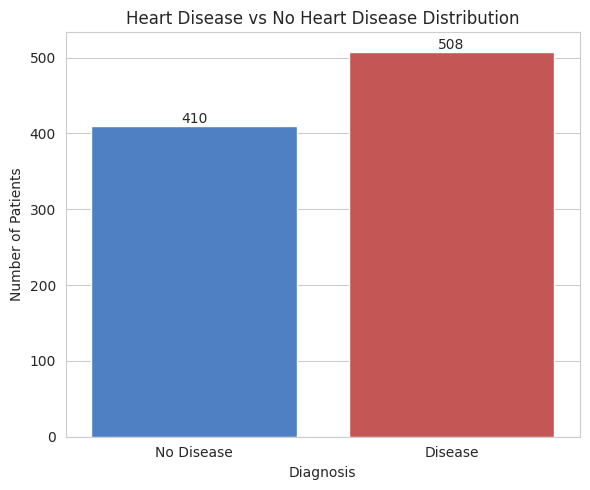

In [11]:
df_eda = df.copy()
df_eda['Diagnosis'] = df_eda['heart_disease'].map({0: 'No Disease', 1: 'Disease'})
PALETTE = {'No Disease': '#3b7dd8', 'Disease': '#d84343'}

plt.figure(figsize=(6,5))
ax = sns.countplot(data=df_eda, x='Diagnosis', hue='Diagnosis', palette=PALETTE, legend=False)
ax.set_title('Heart Disease vs No Heart Disease Distribution')
ax.set_xlabel('Diagnosis'); ax.set_ylabel('Number of Patients')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout(); plt.show()


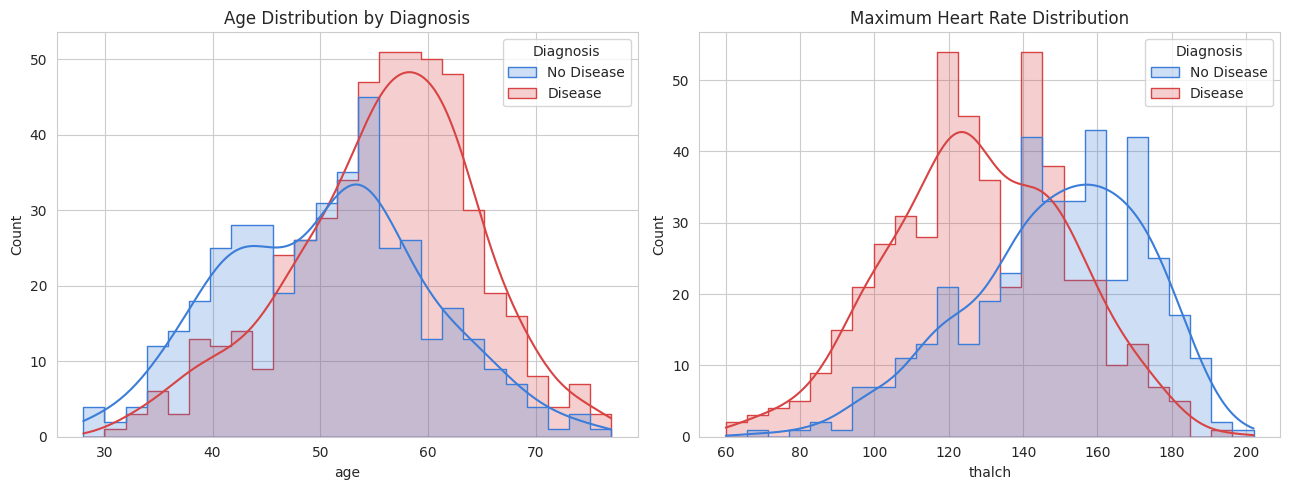

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.histplot(data=df_eda, x='age', hue='Diagnosis', kde=True, palette=PALETTE, element='step', bins=25, ax=axes[0])
axes[0].set_title('Age Distribution by Diagnosis')
sns.histplot(data=df_eda, x='thalch', hue='Diagnosis', kde=True, palette=PALETTE, element='step', bins=25, ax=axes[1])
axes[1].set_title('Maximum Heart Rate Distribution')
plt.tight_layout(); plt.show()


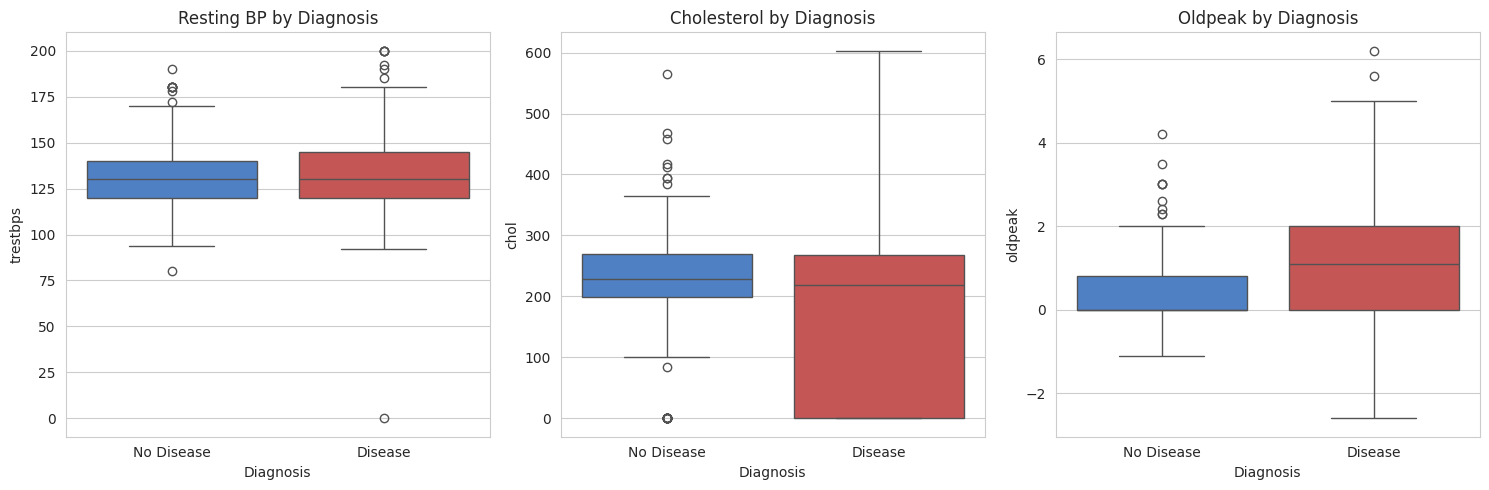

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
sns.boxplot(data=df_eda, x='Diagnosis', y='trestbps', hue='Diagnosis', palette=PALETTE, legend=False, ax=axes[0])
axes[0].set_title('Resting BP by Diagnosis')
sns.boxplot(data=df_eda, x='Diagnosis', y='chol', hue='Diagnosis', palette=PALETTE, legend=False, ax=axes[1])
axes[1].set_title('Cholesterol by Diagnosis')
sns.boxplot(data=df_eda, x='Diagnosis', y='oldpeak', hue='Diagnosis', palette=PALETTE, legend=False, ax=axes[2])
axes[2].set_title('Oldpeak by Diagnosis')
plt.tight_layout(); plt.show()


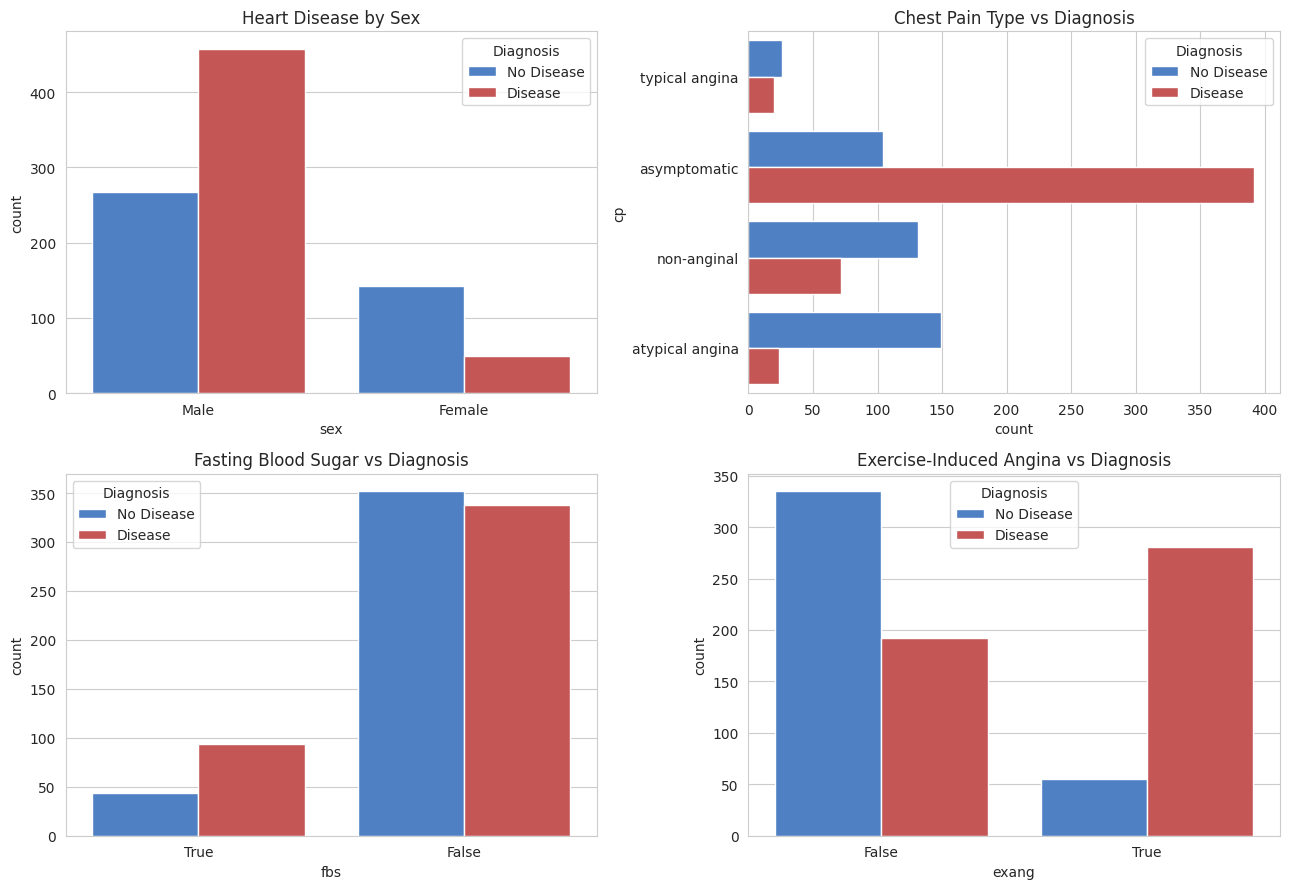

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.countplot(data=df_eda, x='sex', hue='Diagnosis', palette=PALETTE, ax=axes[0,0]); axes[0,0].set_title('Heart Disease by Sex')
sns.countplot(data=df_eda, y='cp', hue='Diagnosis', palette=PALETTE, ax=axes[0,1]); axes[0,1].set_title('Chest Pain Type vs Diagnosis')
sns.countplot(data=df_eda, x='fbs', hue='Diagnosis', palette=PALETTE, ax=axes[1,0]); axes[1,0].set_title('Fasting Blood Sugar vs Diagnosis')
sns.countplot(data=df_eda, x='exang', hue='Diagnosis', palette=PALETTE, ax=axes[1,1]); axes[1,1].set_title('Exercise-Induced Angina vs Diagnosis')
plt.tight_layout(); plt.show()


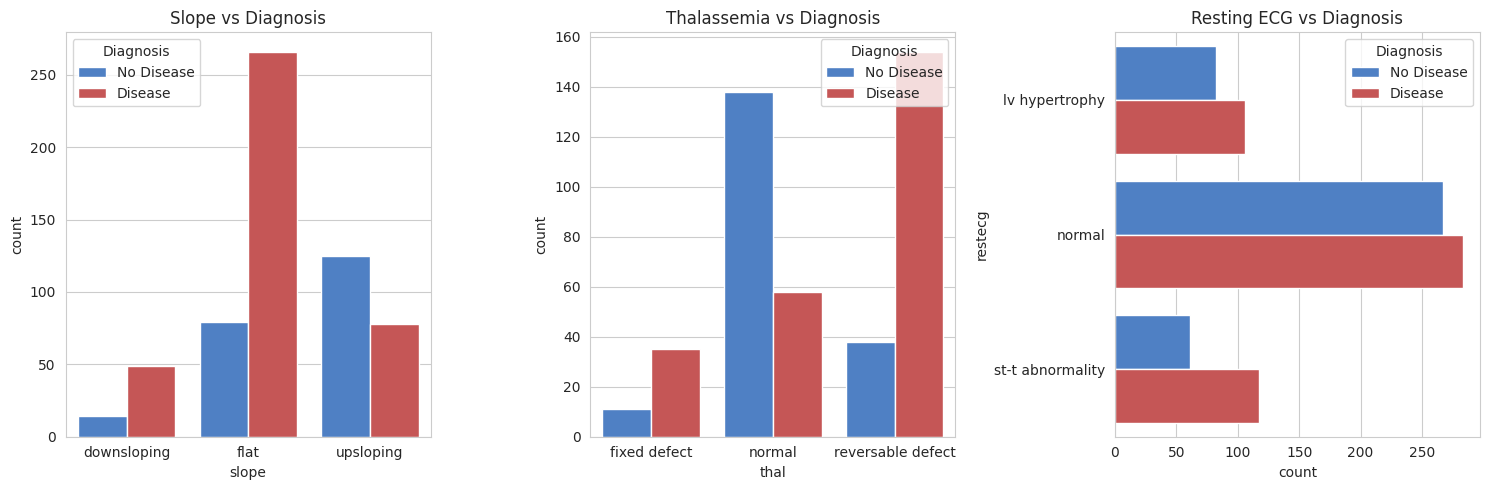

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
sns.countplot(data=df_eda, x='slope', hue='Diagnosis', palette=PALETTE, ax=axes[0]); axes[0].set_title('Slope vs Diagnosis')
sns.countplot(data=df_eda, x='thal', hue='Diagnosis', palette=PALETTE, ax=axes[1]); axes[1].set_title('Thalassemia vs Diagnosis')
sns.countplot(data=df_eda, y='restecg', hue='Diagnosis', palette=PALETTE, ax=axes[2]); axes[2].set_title('Resting ECG vs Diagnosis')
plt.tight_layout(); plt.show()


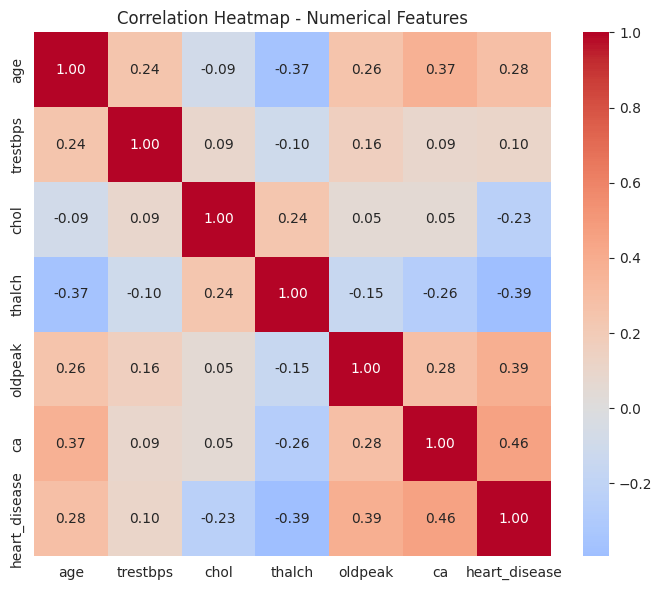

In [16]:
plt.figure(figsize=(7,6))
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'heart_disease']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Numerical Features')
plt.tight_layout(); plt.show()


## 5. Data Preprocessing

Features (`X`) are separated from the target (`y`). Numerical features are median-imputed
and standard-scaled; categorical features are most-frequent-imputed and one-hot encoded.
This is implemented with a `ColumnTransformer` inside a scikit-learn `Pipeline`
(see `src/preprocessing.py`), which is fit **only** on the training data to avoid
data leakage, and re-used unchanged on the test data and on new patient inputs from
the web app.


In [17]:
from preprocessing import get_preprocessor

X = df[ALL_FEATURES]
y = df['heart_disease']
print('Numerical features:', NUMERICAL_FEATURES)
print('Categorical features:', CATEGORICAL_FEATURES)
print('X shape:', X.shape, ' y shape:', y.shape)


Numerical features: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Categorical features: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
X shape: (918, 14)  y shape: (918,)


## 6. Train-Test Split

80% training / 20% testing, `random_state=42`, **stratified** on the target.

Stratification keeps the same proportion of heart-disease-positive cases in both the
training and test sets as in the full dataset. Without it, a random split could, by
chance, under- or over-represent the positive class in the (relatively small) test
set, making evaluation metrics like recall and ROC-AUC noisy and unreliable.


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)
print('Train target ratio:\n', y_train.value_counts(normalize=True))
print('Test target ratio:\n', y_test.value_counts(normalize=True))


Train shape: (734, 14)  Test shape: (184, 14)
Train target ratio:
 heart_disease
1    0.553134
0    0.446866
Name: proportion, dtype: float64
Test target ratio:
 heart_disease
1    0.554348
0    0.445652
Name: proportion, dtype: float64


## 7. Model Training - Logistic Regression & Decision Tree

Both models are wrapped with the same preprocessing pipeline so preprocessing is
applied identically and without leakage.


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42),
}

fitted_pipelines = {}
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', get_preprocessor()), ('classifier', model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
    print(f'{name}: trained.')


Logistic Regression: trained.
Decision Tree: trained.


## 8. Model Evaluation

--- Logistic Regression ---
              precision    recall  f1-score   support

  No Disease       0.88      0.77      0.82        82
     Disease       0.83      0.91      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184



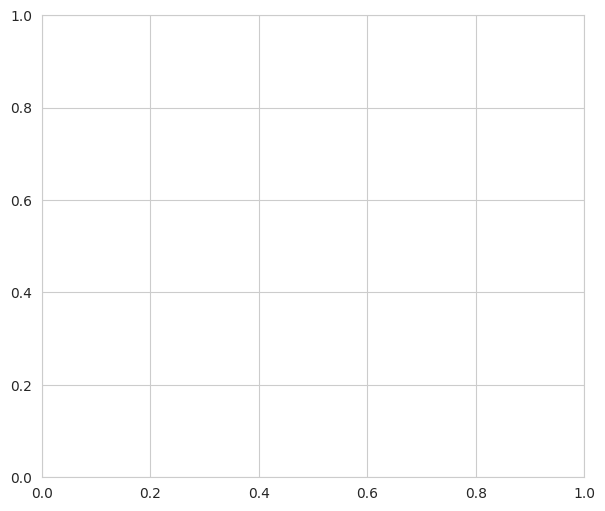

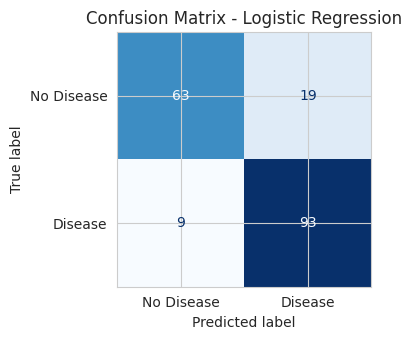

--- Decision Tree ---
              precision    recall  f1-score   support

  No Disease       0.78      0.87      0.82        82
     Disease       0.88      0.80      0.84       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.84      0.83      0.83       184



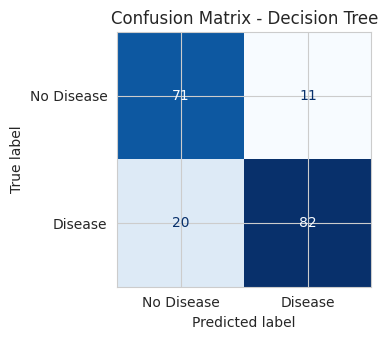

<Figure size 640x480 with 0 Axes>

In [20]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay)

results = []
fig, ax_roc = plt.subplots(figsize=(7,6))

for name, pipe in fitted_pipelines.items():
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    results.append({'Model': name, 'Accuracy': round(acc,4), 'Precision': round(prec,4),
                     'Recall': round(rec,4), 'F1-Score': round(f1,4), 'ROC-AUC': round(auc,4)})

    print(f'--- {name} ---')
    print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

    cm = confusion_matrix(y_test, y_pred)
    fig_cm, ax_cm = plt.subplots(figsize=(4,3.5))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease','Disease']).plot(ax=ax_cm, cmap='Blues', colorbar=False)
    ax_cm.set_title(f'Confusion Matrix - {name}')
    plt.tight_layout(); plt.show()

    RocCurveDisplay.from_predictions(y_test, y_proba, name=name, ax=ax_roc)

ax_roc.plot([0,1],[0,1], linestyle='--', color='gray', label='Chance')
ax_roc.set_title('ROC Curve Comparison')
ax_roc.legend(loc='lower right')
plt.tight_layout(); plt.show()


**What these metrics mean (in simple terms):**
- **Accuracy** - overall proportion of correct predictions.
- **Precision** - of all patients predicted as having heart disease, how many actually do.
- **Recall (Sensitivity)** - of all patients who actually have heart disease, how many the model correctly identifies. This is especially important here, since missing a real positive case is the costlier mistake.
- **F1-score** - the harmonic mean of precision and recall, useful when both matter.
- **ROC-AUC** - the model's ability to distinguish between the two classes across all decision thresholds (1.0 = perfect, 0.5 = random guessing).


## 9. Model Comparison

In [21]:
results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8478,0.8304,0.9118,0.8692,0.9284
1,Decision Tree,0.8315,0.8817,0.8039,0.8410,0.9193


In [22]:
results_df_sorted = results_df.sort_values(by=['ROC-AUC','Recall'], ascending=False).reset_index(drop=True)
best_model_name = results_df_sorted.loc[0, 'Model']
print('Selected final model (by ROC-AUC, tie-break Recall):', best_model_name)


Selected final model (by ROC-AUC, tie-break Recall): Logistic Regression


## 10. Feature Importance / Interpretation

Interpretation below shows which features the *selected* model relies on most.
These are statistical associations learned from this dataset - **not medical
causation** - and should not be read as clinical explanations.


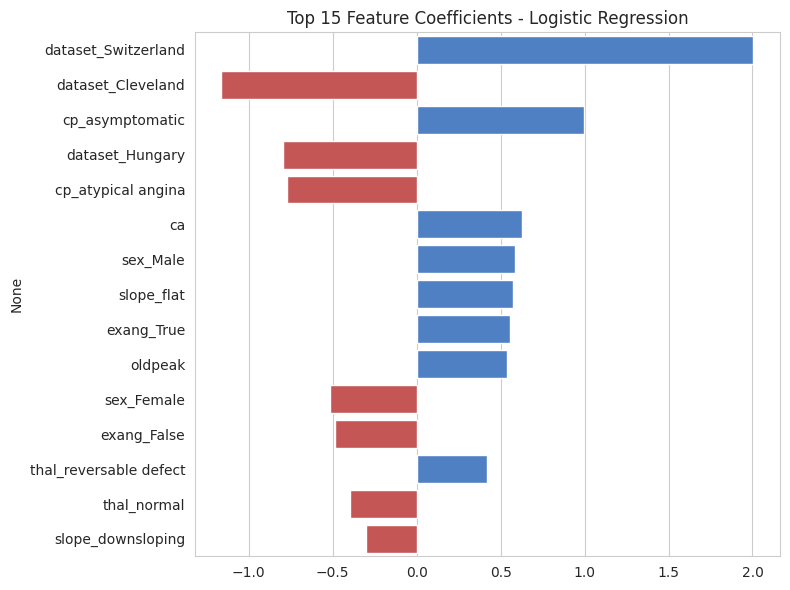

In [23]:
best_pipeline = fitted_pipelines[best_model_name]
preprocessor = best_pipeline.named_steps['preprocessor']
ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = list(ohe.get_feature_names_out(CATEGORICAL_FEATURES))
all_feature_names = NUMERICAL_FEATURES + cat_feature_names

plt.figure(figsize=(8,6))
if best_model_name == 'Decision Tree':
    importances = best_pipeline.named_steps['classifier'].feature_importances_
    imp_series = pd.Series(importances, index=all_feature_names).sort_values(ascending=False).head(15)
    sns.barplot(x=imp_series.values, y=imp_series.index, color='#3b7dd8')
    plt.title(f'Top 15 Feature Importances - {best_model_name}')
else:
    coefs = best_pipeline.named_steps['classifier'].coef_[0]
    coef_series = pd.Series(coefs, index=all_feature_names)
    coef_series = coef_series.reindex(coef_series.abs().sort_values(ascending=False).head(15).index)
    colors = ['#d84343' if v < 0 else '#3b7dd8' for v in coef_series.values]
    sns.barplot(x=coef_series.values, y=coef_series.index, hue=coef_series.index, palette=colors, legend=False)
    plt.title(f'Top 15 Feature Coefficients - {best_model_name}')
plt.tight_layout(); plt.show()


## 11. Save the Final Model Pipeline

The full pipeline (preprocessing + trained classifier) is saved with `joblib` so the
Streamlit web app can load it and directly accept raw, human-readable patient input.
(This is also done by running `python src/train_model.py`, which produces the
`models/heart_disease_model.pkl` file used by the app.)


In [24]:
import joblib
joblib.dump(best_pipeline, '../models/heart_disease_model_notebook.pkl')
print('Saved a copy of the selected pipeline from this notebook run.')
print('\nFinal Model Comparison Table:')
results_df


Saved a copy of the selected pipeline from this notebook run.

Final Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8478,0.8304,0.9118,0.8692,0.9284
1,Decision Tree,0.8315,0.8817,0.8039,0.8410,0.9193


## 12. Conclusion

Both Logistic Regression and a depth-limited Decision Tree were trained on the same
preprocessed features and evaluated on an untouched, stratified 20% test set. The
model comparison table above (produced from actual test-set predictions, not
hard-coded values) was used to select the final model, which is the one saved for
use in the Streamlit web application. See `README.md` for how to run the full
pipeline and the web app, and the project report for a fuller discussion of
methodology, limitations and future scope.
